# 🚆 Fase 1 — EDA
### Public Transport Delays · Omar Mora Flores

**Pregunta central:** ¿cómo afectan el clima y los eventos urbanos a los retrasos del transporte?

Dataset de **2,000 viajes** con clima, eventos y variables temporales. Objetivo: el retraso de
llegada en minutos (`actual_arrival_delay_min`).

> ⚠️ El dataset es pequeño (2,000 filas) → riesgo de overfitting; se priorizará validación
> cruzada y modelos simples en la Fase 3.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "data" / "public_transport_delays.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS = ROOT/"reports"; REPORTS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":130,"axes.titleweight":"bold"})
TARGET = "actual_arrival_delay_min"
df = pd.read_csv(ROOT/"data"/"public_transport_delays.csv")
df["event_type"] = df["event_type"].fillna("None")   # NaN = sin evento
print("Shape:", df.shape)

Shape: (2000, 24)


## 1.1 Descripción y calidad

In [2]:
print("Nulos (tras imputar event_type):", int(df.isnull().sum().sum()))
print("Duplicados:", int(df.duplicated().sum()))
print(f"\n{TARGET}: min %.0f max %.0f mean %.1f"%(df[TARGET].min(),df[TARGET].max(),df[TARGET].mean()))
print("delayed (binario):", dict(df.delayed.value_counts()))
df[[TARGET,"temperature_C","precipitation_mm","traffic_congestion_index"]].describe().round(2).T

Nulos (tras imputar event_type): 0
Duplicados: 0

actual_arrival_delay_min: min -3 max 29 mean 13.3
delayed (binario): {1: np.int64(1499), 0: np.int64(501)}


,count,mean,std,min,25%,50%,75%,max
actual_arrival_delay_min,2000.0,13.32,9.29,-3.0,5.0,13.0,21.0,29.0
temperature_C,2000.0,15.12,11.48,-5.0,5.1,15.3,24.8,35.0
precipitation_mm,2000.0,9.86,5.78,0.0,4.9,9.7,14.8,20.0
traffic_congestion_index,2000.0,50.24,29.23,0.0,25.0,50.0,76.0,99.0


## 1.2 Distribución del retraso

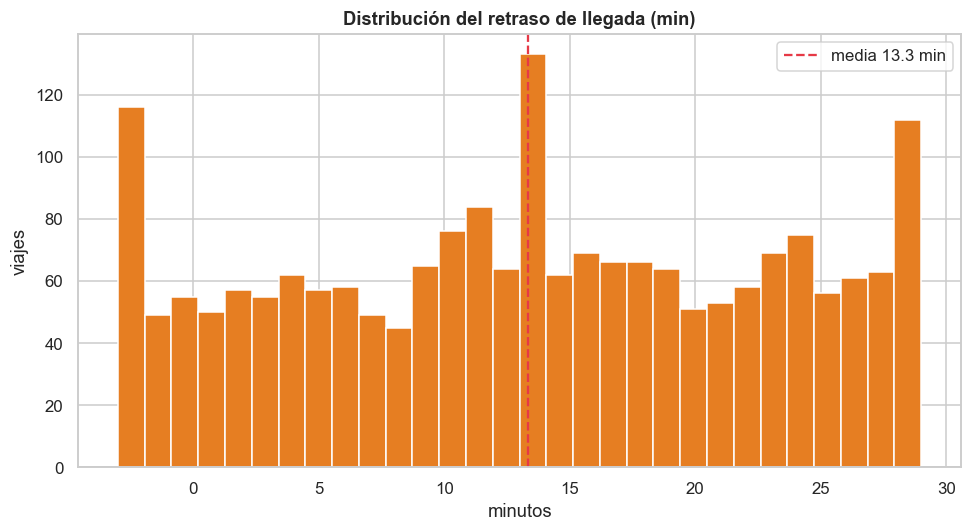

% viajes con retraso (>0): 89.0


In [3]:
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df[TARGET], bins=30, color="#E67E22", edgecolor="white")
ax.axvline(df[TARGET].mean(), ls="--", color="#E63946", label=f"media {df[TARGET].mean():.1f} min")
ax.set_title("Distribución del retraso de llegada (min)"); ax.set_xlabel("minutos"); ax.set_ylabel("viajes"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS/"01_delay_distribution.png", bbox_inches="tight"); plt.show()
print("% viajes con retraso (>0):", round(100*(df[TARGET]>0).mean(),1))

## 1.3 Retrasos por condición climática

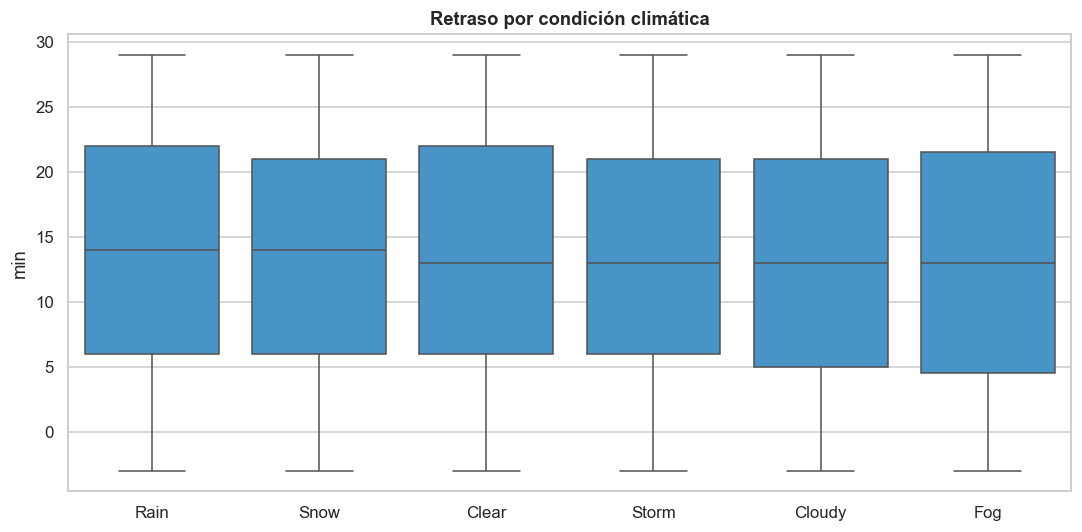

weather_condition
Rain      13.62
Snow      13.53
Clear     13.50
Storm     13.29
Cloudy    13.07
Fog       12.88


In [4]:
orden = df.groupby("weather_condition")[TARGET].mean().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=df, x="weather_condition", y=TARGET, order=orden, ax=ax, color="#3498db")
ax.set_title("Retraso por condición climática"); ax.set_xlabel(""); ax.set_ylabel("min")
fig.tight_layout(); fig.savefig(REPORTS/"02_weather_impact.png", bbox_inches="tight"); plt.show()
print(df.groupby("weather_condition")[TARGET].mean().round(2).sort_values(ascending=False).to_string())

## 1.4 Retrasos por evento de ciudad

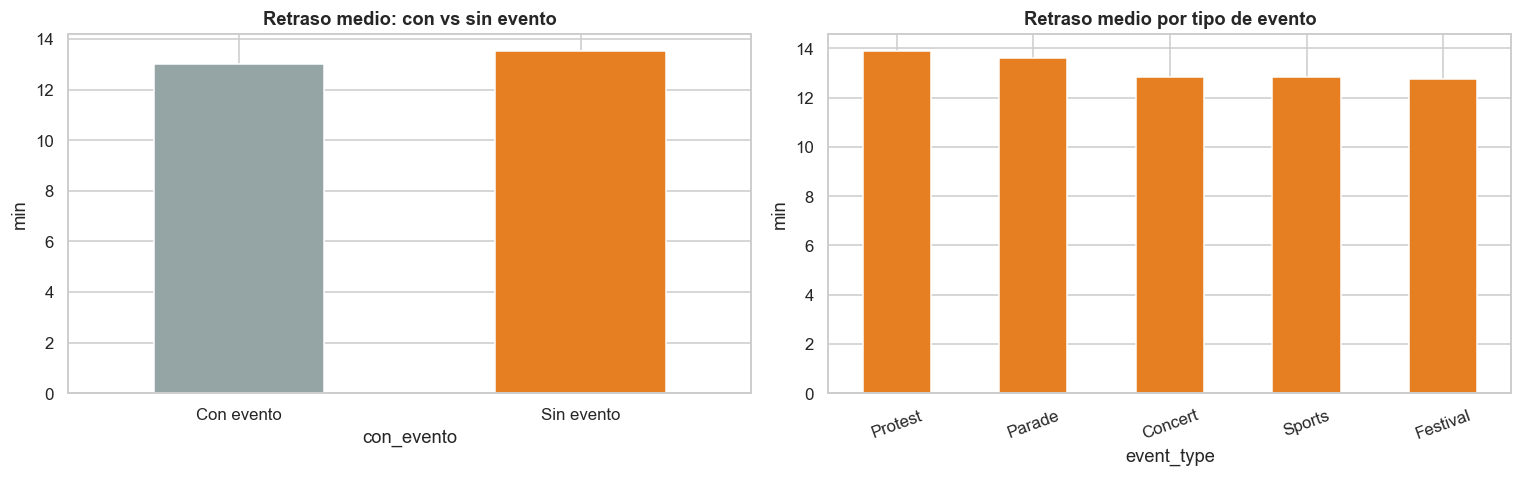

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
df.assign(con_evento=np.where(df.event_type=="None","Sin evento","Con evento")) \
  .groupby("con_evento")[TARGET].mean().plot.bar(ax=ax[0], color=["#95a5a6","#E67E22"])
ax[0].set_title("Retraso medio: con vs sin evento"); ax[0].set_ylabel("min"); ax[0].tick_params(axis='x',rotation=0)
ev = df[df.event_type!="None"].groupby("event_type")[TARGET].mean().sort_values(ascending=False)
ev.plot.bar(ax=ax[1], color="#E67E22"); ax[1].set_title("Retraso medio por tipo de evento"); ax[1].set_ylabel("min"); ax[1].tick_params(axis='x',rotation=20)
fig.tight_layout(); fig.savefig(REPORTS/"03_events_impact.png", bbox_inches="tight"); plt.show()

## 1.5 Análisis temporal (día × hora pico)

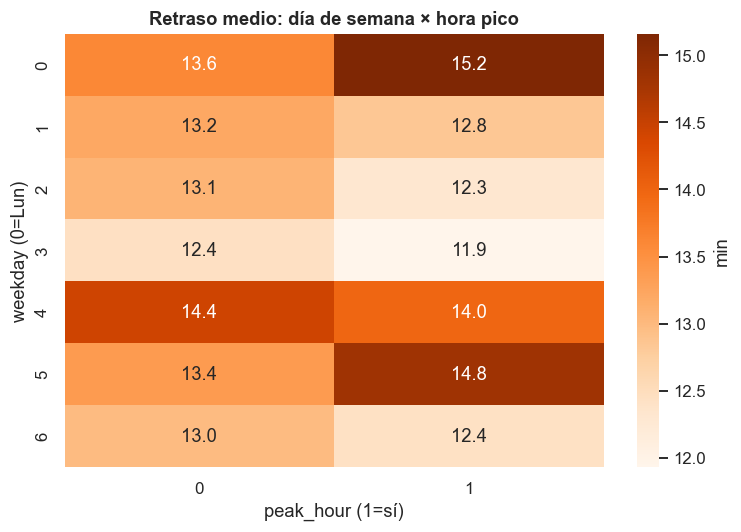

In [6]:
piv = df.pivot_table(index="weekday", columns="peak_hour", values=TARGET, aggfunc="mean")
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(piv, annot=True, fmt=".1f", cmap="Oranges", ax=ax, cbar_kws={"label":"min"})
ax.set_title("Retraso medio: día de semana × hora pico"); ax.set_xlabel("peak_hour (1=sí)"); ax.set_ylabel("weekday (0=Lun)")
fig.tight_layout(); fig.savefig(REPORTS/"04_temporal_heatmap.png", bbox_inches="tight"); plt.show()

## 1.6 Correlación de variables numéricas con el retraso

Correlación con el retraso:
 temperature_C                -0.040
event_attendance_est          0.037
holiday                       0.034
humidity_percent             -0.028
traffic_congestion_index     -0.011
weekday                      -0.008
wind_speed_kmh               -0.008
actual_departure_delay_min   -0.007
peak_hour                     0.003
precipitation_mm              0.001


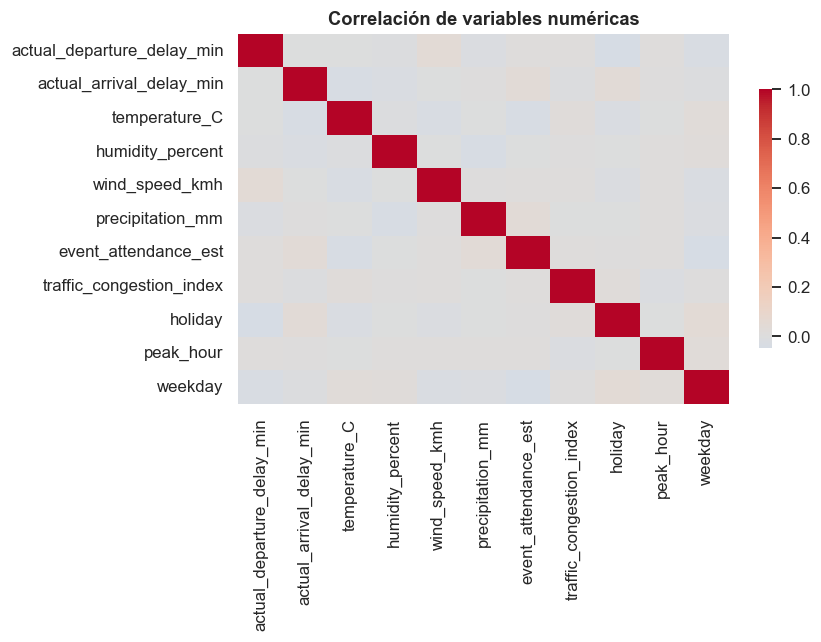

In [7]:
num = df.select_dtypes("number").drop(columns=["delayed"])  # delayed = target binarizado (leakage)
corr = num.corr()[TARGET].drop(TARGET).sort_values(key=lambda s:s.abs(), ascending=False)
print("Correlación con el retraso:\n", corr.round(3).to_string())
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(num.corr(), cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink":.7})
ax.set_title("Correlación de variables numéricas")
fig.tight_layout(); fig.savefig(REPORTS/"05_correlation.png", bbox_inches="tight"); plt.show()

## 1.6 Conclusiones del EDA

1. **Retraso medio ~13 min**; la mayoría de viajes registran algún retraso.
2. **Señal débil de las features:** clima y eventos muestran diferencias modestas y las
   correlaciones numéricas con el retraso son **cercanas a 0** — el dataset (sintético, 2,000
   filas) tiene poca capacidad predictiva. Es un hallazgo a documentar honestamente.
3. **`delayed` es el target binarizado** (corr 0.76) → se excluye como feature para evitar
   *data leakage*.
4. El tamaño pequeño obliga a **validación cruzada** y modelos simples en la Fase 3.

➡️ **Siguiente:** `02_preprocessing.ipynb` (encoding + split) y `03_modeling.ipynb` (regresión).